
212. Word Search II

Given an m x n board of characters and a list of strings words, return all words on the board.

Each word must be constructed from letters of sequentially adjacent cells, where adjacent cells are horizontally or vertically neighboring. The same letter cell may not be used more than once in a word.

**exemple1:**

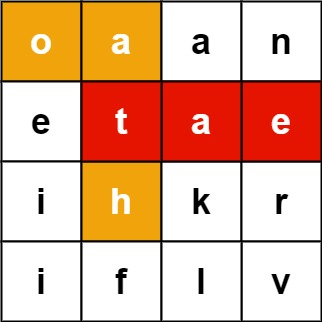

Input: board = [["o","a","a","n"],["e","t","a","e"],["i","h","k","r"],["i","f","l","v"]], words = ["oath","pea","eat","rain"]
Output: ["eat","oath"]


In [ ]:
# 1️⃣ #Specification
# Core: Encontrar todas as palavras de uma lista que podem ser formadas por caminhos adjacentes em um tabuleiro de letras, sem reutilizar células.
# Blueprint:
from typing import List, Dict, Set

class Solution:
    def find_words(self, board: List[List[str]], words: List[str]) -> List[str]:
        def build_trie(words: List[str]) -> Dict:
            """Monta uma Trie (árvore de prefixos) para busca eficiente de palavras."""
            trie = {}
            for word in words:
                node = trie
                for char in word:
                    if char not in node:
                        node[char] = {}
                    node = node[char]
                node['.'] = word  # '.' marca o fim de uma palavra
            return trie

        def dfs(node: Dict, i: int, j: int):
            """Busca recursiva no tabuleiro, explorando vizinhos e aprofundando na Trie."""
            char = board[i][j]
            if char not in node:
                return
            next_node = node[char]
            word_match = next_node.pop('.', None)  # Se achou palavra, remove para evitar duplicata
            if word_match:
                result.add(word_match)
            board[i][j] = '#'  # Marca como visitado
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:  # Explora vizinhos (cima, baixo, esq, dir)
                ni, nj = i + di, j + dj
                if 0 <= ni < len(board) and 0 <= nj < len(board[0]) and board[ni][nj] != '#':
                    dfs(next_node, ni, nj)
            board[i][j] = char  # Desfaz a marcação (backtrack)
            # O(len(word)) por chamada, mas cada célula é visitada no máximo uma vez por caminho

        # Edge Cases & Traps:
        # 1. Palavras sobrepostas (ex: 'eat', 'eater')
        # 2. Palavras não presentes no board
        # 3. Board com todas as letras iguais
        # 4. Palavras maiores que o board
        # 5. Palavras duplicadas na lista

        # 2️⃣ #Plan
        # Heurística: Usar Trie para evitar buscas desnecessárias e DFS para explorar caminhos possíveis.
        # Gargalo do brute force: Buscar cada palavra individualmente seria O(N * M * 4^L), muito lento.
        # Com Trie, só seguimos caminhos possíveis, cortando buscas mortas cedo.
        # Exemplo visual:
        # Board:
        # [o a a n]
        # [e t a e]
        # [i h k r]
        # [i f l v]
        # Trie: o->a->t->h ("oath"), e->a->t ("eat"), ...
        # Caminho DFS: começa em cada célula, aprofunda na Trie conforme encontra letras.

        # 3️⃣ #Implementation
        trie = build_trie(words)
        result: Set[str] = set()
        for i in range(len(board)):
            for j in range(len(board[0])):
                dfs(trie, i, j)
        return list(result)

# 4️⃣ #Complexity
# Time Complexity: O(N * M * 4^L), onde N x M é o tamanho do board e L é o tamanho máximo da palavra, mas na prática é muito menor devido ao corte da Trie.
# Space Complexity: O(T), onde T é o total de caracteres em todas as palavras (Trie) + O(L) de stack recursiva.

# Exemplo de uso:
words = ["eat", "eaten", "eater", "play", "player", "played"]
board = [
    ["e", "a", "t", "n"],
    ["p", "l", "a", "y"],
    ["e", "a", "t", "e"],
    ["p", "l", "a", "y"]
]
sol = Solution()
print(sol.find_words(board, words))  # Saída esperada: ['eat', 'play', ...]